# Tutorial Part 1 — Math, Primitives & the Fair Objective

This tutorial builds **Fair Kernel Ridge Regression** from first
principles using only `fairkl` primitives and `keras.ops`.

**Outline**

1. Kernel ridge regression from scratch
2. The fairness problem — why standard KRR is unfair
3. Measuring dependence — HSIC vs CKA
4. The fair KRR objective
5. Canonical plot — fairness vs accuracy

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import keras.ops as ops
import matplotlib.pyplot as plt
import numpy as np

import fairkl
from _style import SCATTER_KW, style_ax

## Synthetic Data

We use $y = \sin(x) + 3q + \varepsilon$ so that:

- The relationship with $x$ is **nonlinear** (kernels help).
- The target is **strongly coupled** to the sensitive attribute $q$.

In [2]:
rng = np.random.default_rng(0)
n = 200
x = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x, q]).astype("float32")
y = (np.sin(x.ravel()) + 3.0 * q.ravel() + 0.3 * rng.standard_normal(n)).astype(
    "float32"
)

print(f"n = {n},  d = {X.shape[1]}")
print(f"Corr(y, q) = {np.corrcoef(y, q.ravel())[0, 1]:.3f}")

n = 200,  d = 2
Corr(y, q) = 0.972


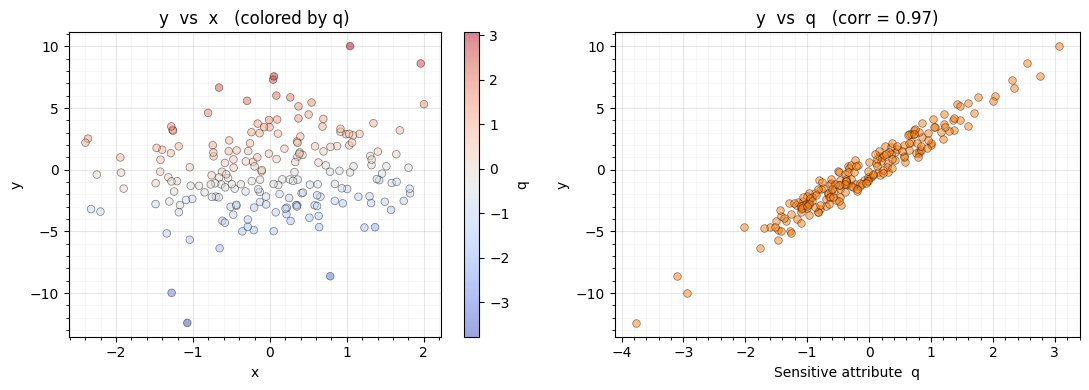

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sc = axes[0].scatter(x.ravel(), y, c=q.ravel(), cmap="coolwarm", **SCATTER_KW)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("y  vs  x   (colored by q)")
plt.colorbar(sc, ax=axes[0], label="q")
style_ax(axes[0])

axes[1].scatter(q.ravel(), y, c="C1", **SCATTER_KW)
axes[1].set_xlabel("Sensitive attribute  q")
axes[1].set_ylabel("y")
axes[1].set_title(f"y  vs  q   (corr = {np.corrcoef(y, q.ravel())[0, 1]:.2f})")
style_ax(axes[1])
plt.tight_layout()
plt.show()

---
## 1  Kernel Ridge Regression from Scratch

### 1.1  The kernel matrix

The RBF kernel measures similarity between data points:

$$K_{ij} = \exp\!\Bigl(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\Bigr)$$

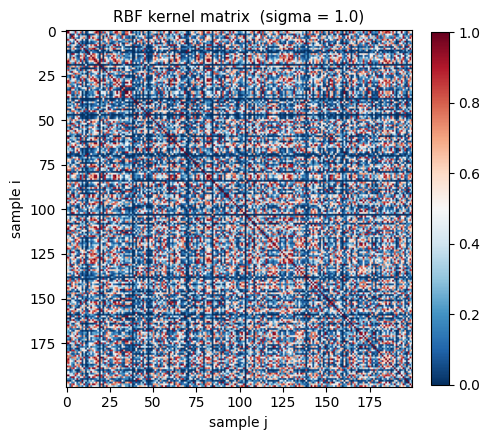

In [4]:
sigma = 1.0
K = np.array(fairkl.rbf_kernel(X, sigma=sigma))

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(K, cmap="RdBu_r", aspect="auto")
ax.set_title(f"RBF kernel matrix  (sigma = {sigma})", fontsize=11)
ax.set_xlabel("sample j")
ax.set_ylabel("sample i")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### 1.2  Centering

Centering the kernel matrix removes the mean in the feature space:
$\tilde{K} = HKH$ where $H = I - \tfrac{1}{n}\mathbf{1}\mathbf{1}^\top$.
In practice we use the efficient formula
$\tilde{K}_{ij} = K_{ij} - \bar{K}_{i\cdot} - \bar{K}_{\cdot j} + \bar{K}_{\cdot\cdot}$.

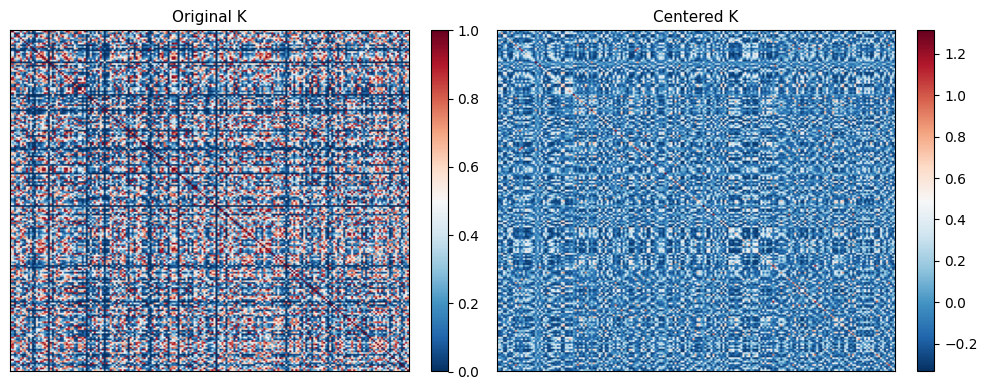

In [5]:
K_centered = np.array(fairkl.center_kernel(K))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(K, cmap="RdBu_r", aspect="auto")
axes[0].set_title("Original K", fontsize=11)
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(K_centered, cmap="RdBu_r", aspect="auto")
axes[1].set_title("Centered K", fontsize=11)
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

### 1.3  The dual solution

Standard KRR minimizes

$$\min_\alpha \;\|K\alpha - y\|^2 + \lambda\,\alpha^\top K\alpha$$

The solution is $\alpha = (K + \lambda I)^{-1} y$, which we solve via
Cholesky factorization.

In [6]:
lam = 0.01
K_t = ops.convert_to_tensor(K, dtype="float32")
y_t = ops.convert_to_tensor(y.reshape(-1, 1), dtype="float32")
n_t = ops.shape(K_t)[0]

system = K_t + lam * ops.eye(n_t)
alpha = fairkl.solve_cholesky(system, y_t)

y_pred_std = np.array(ops.matmul(K_t, alpha)).ravel()
mse_std = float(np.mean((y_pred_std - y) ** 2))
print(f"Standard KRR — MSE = {mse_std:.4f}")

Standard KRR — MSE = 0.0742


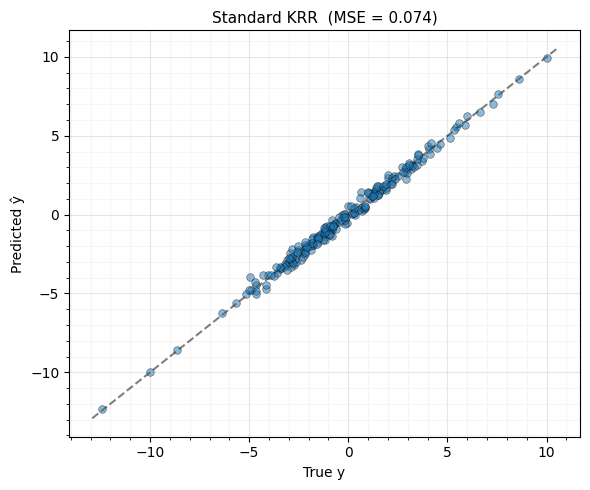

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y, y_pred_std, c="C0", **SCATTER_KW)
lo, hi = y.min() - 0.5, y.max() + 0.5
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, alpha=0.5)
ax.set_xlabel("True y")
ax.set_ylabel("Predicted ŷ")
ax.set_title(f"Standard KRR  (MSE = {mse_std:.3f})", fontsize=11)
style_ax(ax)
plt.tight_layout()
plt.show()

### 1.4  Bandwidth effect

The bandwidth $\sigma$ controls how "local" the kernel is.
Too small → interpolation; too large → underfitting.

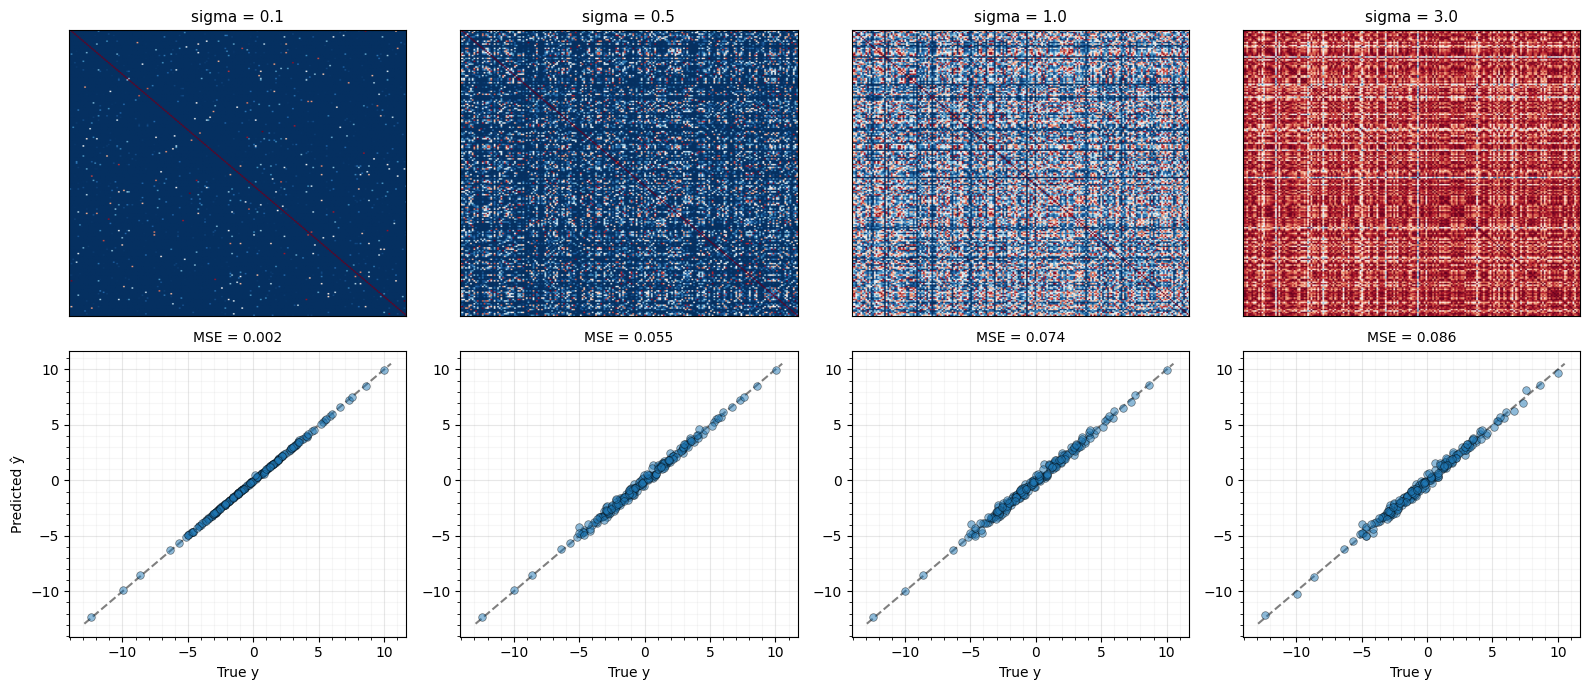

In [8]:
sigmas = [0.1, 0.5, 1.0, 3.0]
fig, axes = plt.subplots(2, len(sigmas), figsize=(16, 7))

for j, s in enumerate(sigmas):
    K_s = np.array(fairkl.rbf_kernel(X, sigma=s))
    # Heatmap
    im = axes[0, j].imshow(K_s, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    axes[0, j].set_title(f"sigma = {s}", fontsize=11)
    axes[0, j].set_xticks([])
    axes[0, j].set_yticks([])
    # Predictions
    K_s_t = ops.convert_to_tensor(K_s, dtype="float32")
    sys_s = K_s_t + lam * ops.eye(n_t)
    a_s = fairkl.solve_cholesky(sys_s, y_t)
    yh_s = np.array(ops.matmul(K_s_t, a_s)).ravel()
    mse_s = float(np.mean((yh_s - y) ** 2))
    axes[1, j].scatter(y, yh_s, c="C0", **SCATTER_KW)
    axes[1, j].plot([lo, hi], [lo, hi], "k--", lw=1.5, alpha=0.5)
    axes[1, j].set_title(f"MSE = {mse_s:.3f}", fontsize=10)
    axes[1, j].set_xlabel("True y")
    if j == 0:
        axes[1, j].set_ylabel("Predicted ŷ")
    style_ax(axes[1, j])

plt.tight_layout()
plt.show()

---
## 2  The Fairness Problem

### 2.1  Standard KRR exploits the sensitive attribute

Because $y$ depends on $q$, the optimal predictor *uses* $q$ — the
predictions are strongly correlated with the sensitive attribute.

Corr(ŷ, q) = 0.975  — predictions are highly dependent on q


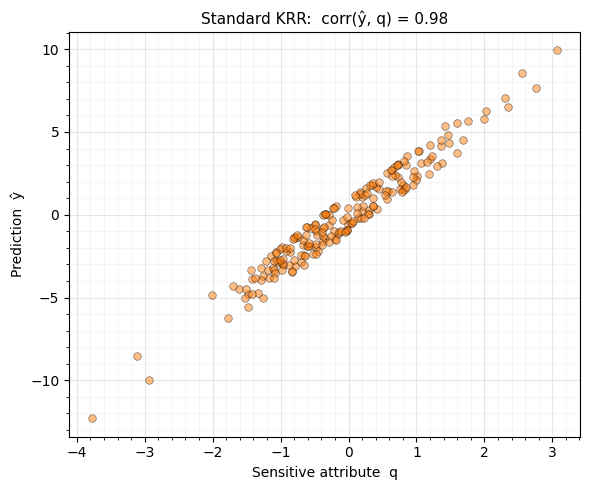

In [9]:
corr_std = np.corrcoef(y_pred_std, q.ravel())[0, 1]
print(f"Corr(ŷ, q) = {corr_std:.3f}  — predictions are highly dependent on q")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(q.ravel(), y_pred_std, c="C1", **SCATTER_KW)
ax.set_xlabel("Sensitive attribute  q")
ax.set_ylabel("Prediction  ŷ")
ax.set_title(f"Standard KRR:  corr(ŷ, q) = {corr_std:.2f}", fontsize=11)
style_ax(ax)
plt.tight_layout()
plt.show()

### 2.2  Measuring dependence: HSIC and CKA

**HSIC** (Hilbert-Schmidt Independence Criterion) measures statistical
dependence between two variables via their kernel matrices:

$$\text{HSIC}(K_f, K_q) = \frac{1}{n^2}\operatorname{tr}(\tilde K_f\,\tilde K_q)$$

**CKA** (Centered Kernel Alignment) normalizes HSIC to $[0, 1]$:

$$\text{CKA}(K_f, K_q) = \frac{\text{HSIC}(K_f, K_q)}{\sqrt{\text{HSIC}(K_f, K_f)\,\text{HSIC}(K_q, K_q)}}$$

In [10]:
# Build kernel matrices on predictions and sensitive attribute
K_yhat = np.array(fairkl.rbf_kernel(y_pred_std.reshape(-1, 1), sigma=1.0))
K_q = np.array(fairkl.rbf_kernel(q, sigma=1.0))

hsic_val = float(fairkl.hsic_biased(K_yhat, K_q))
cka_val = float(fairkl.cka_biased(K_yhat, K_q))
print(f"HSIC = {hsic_val:.6f}")
print(f"CKA  = {cka_val:.4f}   (0 = independent, 1 = fully dependent)")

HSIC = 0.054620
CKA  = 0.6467   (0 = independent, 1 = fully dependent)


### 2.3  Why CKA over HSIC?

**Boundedness**: CKA is always in $[0, 1]$, so the penalty weight
$\mu$ is interpretable regardless of data scale or sample size.
HSIC is unbounded and its magnitude depends on $n$ and $\sigma$.

**Scale invariance (linear kernels)**: with linear kernels,
$\text{HSIC}(cf, q) = c^2 \cdot \text{HSIC}(f, q)$, while
$\text{CKA}(cf, q) = \text{CKA}(f, q)$ — the $c^2$ cancels
in the ratio.  With RBF kernels and fixed bandwidth, both
metrics change when data is scaled (the kernel matrix itself
changes), so the advantage is specifically about normalization.

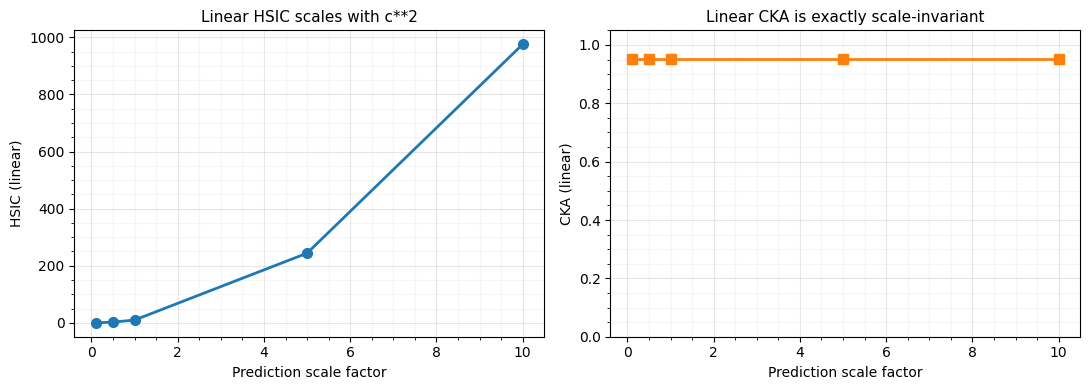

In [11]:
# Demonstrate with linear kernels where the difference is exact
scales = [0.1, 0.5, 1.0, 5.0, 10.0]
hsic_lin_vals, cka_lin_vals = [], []

for s in scales:
    y_scaled = (y_pred_std * s).reshape(-1, 1).astype("float32")
    hsic_lin_vals.append(float(fairkl.hsic_linear(y_scaled, q)))
    cka_lin_vals.append(float(fairkl.cka_linear(y_scaled, q)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(scales, hsic_lin_vals, "o-", color="C0", lw=2, markersize=7)
axes[0].set_xlabel("Prediction scale factor")
axes[0].set_ylabel("HSIC (linear)")
axes[0].set_title("Linear HSIC scales with c**2", fontsize=11)
style_ax(axes[0])

axes[1].plot(scales, cka_lin_vals, "s-", color="C1", lw=2, markersize=7)
axes[1].set_xlabel("Prediction scale factor")
axes[1].set_ylabel("CKA (linear)")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Linear CKA is exactly scale-invariant", fontsize=11)
style_ax(axes[1])
plt.tight_layout()
plt.show()

---
## 3  The Fair KRR Objective

We add a CKA penalty to the KRR objective:

$$\min_\alpha \;\underbrace{\|K\alpha - y\|^2}_{\text{data fit}}
+ \;\lambda\underbrace{\alpha^\top K\alpha}_{\text{ridge}}
+ \;\mu\underbrace{\text{CKA}(K\alpha,\; q)}_{\text{fairness}}$$

- $\mu = 0$: standard KRR (closed-form solution).
- $\mu > 0$: gradient descent is needed (the CKA term is nonlinear in
  $\alpha$). The `FairKernelRidge` model handles this internally.

### 3.1  Loss decomposition

Let's evaluate each term for the **unfair** solution at different $\mu$
values.

In [12]:
alpha_np = np.array(alpha)
K_np = np.array(K_t)

pred = K_np @ alpha_np
mse_term = float(np.mean((pred - y.reshape(-1, 1)) ** 2))
ridge_term = float(lam * np.sum(alpha_np * (K_np @ alpha_np)))
cka_term = float(fairkl.cka_rbf(pred.astype("float32"), q, sigma_q=1.0))

print("Loss decomposition for the unfair (μ=0) solution:")
print(f"  MSE   = {mse_term:.4f}")
print(f"  Ridge = {ridge_term:.4f}")
print(f"  CKA   = {cka_term:.4f}")
print()

mus_demo = [0, 1, 5, 10, 20]
print(f"{'μ':>4s}  {'MSE':>7s}  {'λ·ridge':>8s}  {'μ·CKA':>7s}  {'total':>8s}")
print("-" * 42)
for mu in mus_demo:
    total = mse_term + ridge_term + mu * cka_term
    print(
        f"{mu:4d}  {mse_term:7.4f}  {ridge_term:8.4f}"
        f"  {mu * cka_term:7.4f}  {total:8.4f}"
    )

Loss decomposition for the unfair (μ=0) solution:
  MSE   = 0.0742
  Ridge = 4.0807
  CKA   = 0.6467

   μ      MSE   λ·ridge    μ·CKA     total
------------------------------------------
   0   0.0742    4.0807   0.0000    4.1549
   1   0.0742    4.0807   0.6467    4.8016
   5   0.0742    4.0807   3.2333    7.3882
  10   0.0742    4.0807   6.4666   10.6215
  20   0.0742    4.0807  12.9332   17.0881


The CKA penalty grows with $\mu$, pushing the optimizer to find
solutions that reduce dependence on $q$ — at the cost of higher MSE.

### 3.2  What `model.fit()` does internally

When `mu > 0`, `FairKernelRidge.fit()`:

1. Computes the **exact KRR solution** $(K + \lambda I)^{-1} y$ as a warm start.
2. Runs **Adam** on the full loss (MSE + ridge + CKA) starting from that warm start.

Let's verify: with `mu=0`, the model's solution matches our manual solve.

In [13]:
model_std = fairkl.FairKernelRidge(sigma=sigma, lam=lam, mu=0.0)
model_std.fit(X, y)
alpha_model = np.array(model_std.get_alpha())

diff = float(np.max(np.abs(alpha_np - alpha_model)))
print(f"Max |alpha_manual - alpha_model| = {diff:.2e}  (should be ~0)")

Max |alpha_manual - alpha_model| = 0.00e+00  (should be ~0)


---
## 4  Canonical Plot — Fairness vs Accuracy

We sweep $\mu$ and plot the **Pareto frontier**: MSE (accuracy) against
CKA (fairness).  Each point is a different trade-off.

In [14]:
mus = [0, 1, 5, 10, 20]
mse_list, cka_list = [], []

for mu in mus:
    model = fairkl.FairKernelRidge(sigma=1.0, lam=0.01, mu=mu, sigma_q=1.0)
    model.fit(X, y, q=q, epochs=200, lr=0.005)
    yh = np.array(model.predict(X)).ravel()
    mse = float(np.mean((yh - y) ** 2))
    cka_val = float(fairkl.cka_rbf(yh.reshape(-1, 1), q))
    mse_list.append(mse)
    cka_list.append(cka_val)
    print(f"μ = {mu:5.1f}   MSE = {mse:.3f}   CKA = {cka_val:.3f}")

μ =   0.0   MSE = 0.074   CKA = 0.647


μ =   1.0   MSE = 0.337   CKA = 0.626


μ =   5.0   MSE = 1.018   CKA = 0.350


μ =  10.0   MSE = 2.111   CKA = 0.191


μ =  20.0   MSE = 3.809   CKA = 0.075


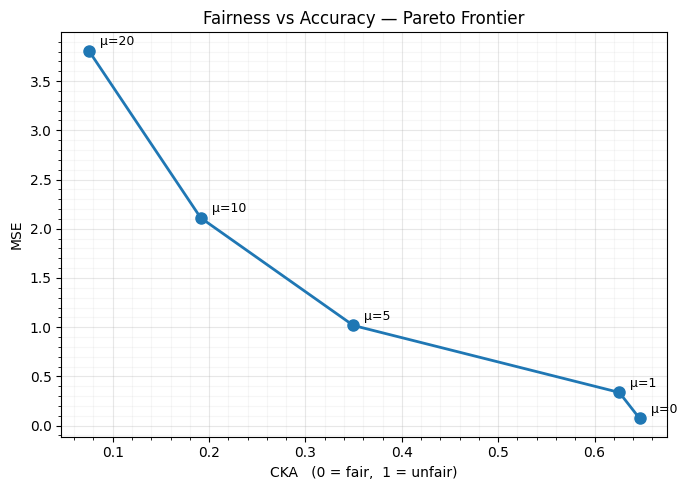

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cka_list, mse_list, "o-", color="C0", lw=2, markersize=8)
for i, mu in enumerate(mus):
    ax.annotate(
        f"μ={mu}",
        (cka_list[i], mse_list[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
    )
ax.set_xlabel("CKA   (0 = fair,  1 = unfair)")
ax.set_ylabel("MSE")
ax.set_title("Fairness vs Accuracy — Pareto Frontier", fontsize=12)
style_ax(ax)
plt.tight_layout()
plt.show()

**Key takeaway**: increasing $\mu$ reduces CKA (makes predictions
fairer) at the cost of higher MSE (less accurate predictions).
The Pareto frontier visualizes this trade-off and helps practitioners
choose an operating point.

---

**Next**: [Part 2](tutorial_fair_krr_part2.py) wraps the model with
scikit-learn for cross-validated hyperparameter selection.